In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import EarthLocation, AltAz, SkyCoord, ICRS
from astropy.time import Time
import astropy.units as u

In [15]:
df = pd.read_csv('with_time.csv')
df.head()
zenith = df['Zenith'].values
azimuth = df['Azimuth'].values
time_min = df['Time'].values

In [12]:
lat = 51 + 46/60
lon = 104 + 24/60
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)
date_obs = '2019-01-01'

In [16]:
date0 = Time('2019-01-01 00:00:00', scale='utc')

In [17]:
ra_list = []
dec_list = []

In [18]:
for i in range(len(zenith)):
    t_min = time_min[i]
    if t_min <= 0:
        # Если время не задано, можно пропустить или заменить случайным
        # Здесь пропустим (continue)
        continue
    # Переводим минуты в секунды и добавляем к началу суток
    offset_sec = t_min * 60.0
    obstime = date0 + offset_sec * u.s

    # Высота = 90 - зенит
    alt = 90.0 - zenith[i]
    az = azimuth[i]

    altaz = AltAz(alt=alt*u.deg, az=az*u.deg, obstime=obstime, location=location)
    coord = SkyCoord(altaz).transform_to(ICRS)
    ra_list.append(coord.ra.deg)
    dec_list.append(coord.dec.deg)

In [19]:
df_filtered = df.iloc[:len(ra_list)].copy()  # если пропускали события
df_filtered['ra'] = ra_list
df_filtered['dec'] = dec_list

In [20]:
df_filtered.to_csv('radec_output.csv', index=False)

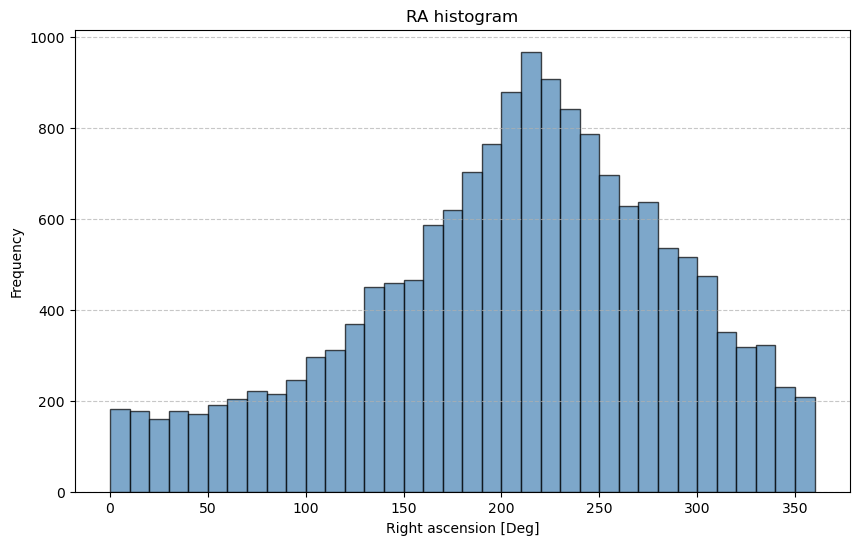

In [23]:
plt.figure(figsize=(10,6))
plt.hist(ra_list, bins=36, range=(0,360), color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Right ascension [Deg]')
plt.ylabel('Frequency')
plt.title('RA histogram')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

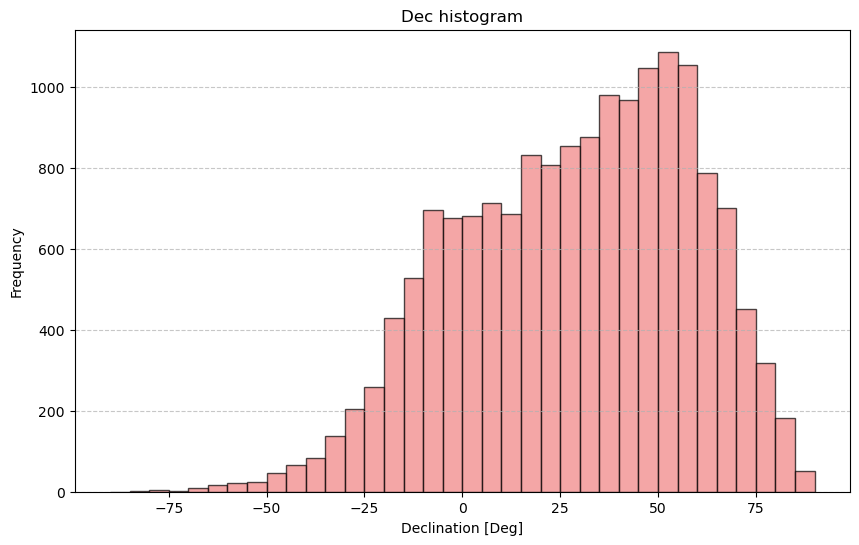

In [24]:
plt.figure(figsize=(10,6))
plt.hist(dec_list, bins=36, range=(-90,90), color='lightcoral', edgecolor='black', alpha=0.7)
plt.xlabel('Declination [Deg]')
plt.ylabel('Frequency')
plt.title('Dec histogram')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [26]:
df_filtered.describe()

,Zenith,Azimuth,Time,ra,dec
count,16285.000000,16285.000000,16285.000000,16285.000000,16285.000000
mean,52.802131,180.577162,70.962104,204.549333,28.825474
std,24.566976,103.551853,127.158454,80.938497,29.628979
min,0.000000,0.070679,0.016119,0.081828,-83.265815
25%,35.563000,94.859700,12.682700,155.003992,6.359211
50%,55.059400,174.363000,34.957000,213.083224,32.128764
75%,68.268600,270.504000,86.272400,262.225179,52.600528
max,176.077000,359.995000,5984.550000,359.799878,89.891386


In [2]:
pwd

'C:\\Users\\User'